# 6 #
In this exercise, you will further analyze the Wage data set considered
throughout this chapter.

(a) Perform polynomial regression to predict wage using age. Use cross-validation to select the optimal degree d for the polynomial. What degree was chosen, and how does this compare to the results of hypothesis testing using ANOVA? Make a plot of the resulting polynomial fit to the data.

In [414]:
import numpy as np
import pandas as pd
from ISLP import load_data
from ISLP.models import (summarize,
                         ModelSpec,
                         poly)
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from statsmodels.stats.anova import anova_lm
from statsmodels.api import OLS
from matplotlib.pyplot import subplots

Wage =  load_data('Wage')
Wage.head(3)

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177


In [415]:
X_age = Wage[['age']]
y = Wage['wage'] 

In [416]:
pipe_age_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=1)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])
grid_poly = {'poly__degree': range(0,6)}

linear_poly_cv = GridSearchCV(pipe_age_poly, grid_poly, cv=5, scoring='neg_mean_squared_error')
linear_poly_cv.fit(X_age, y)
linear_poly_cv.best_params_

{'poly__degree': 4}

In [417]:
pd.DataFrame(linear_poly_cv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_poly__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005091,0.001962,0.004610,0.003705,0,{'poly__degree': 0},-1938.282682,-1630.420540,-1586.901932,-1739.892246,-1811.178750,-1741.335230,126.348890,6
1,0.004225,0.000905,0.002027,0.000670,1,{'poly__degree': 1},-1878.151560,-1568.713243,-1526.157551,-1681.168895,-1720.879941,-1675.014238,123.987523,5
2,0.003735,0.000713,0.001409,0.000089,2,{'poly__degree': 2},-1763.238962,-1489.123713,-1459.204994,-1621.776055,-1664.647410,-1599.598227,112.620087,4
3,0.005274,0.001233,0.001851,0.000332,3,{'poly__degree': 3},-1759.055177,-1487.270483,-1448.413468,-1616.951224,-1661.940729,-1594.726216,113.991143,2
4,0.003514,0.000183,0.002036,0.000809,4,{'poly__degree': 4},-1760.319050,-1494.086167,-1446.532118,-1611.428666,-1657.204518,-1593.914104,112.862845,1
5,0.003631,0.000755,0.001442,0.000149,5,{'poly__degree': 5},-1759.309580,-1504.745664,-1446.521378,-1610.118476,-1656.470557,-1595.433131,110.630596,3


Text(0, 0.5, 'MSE')

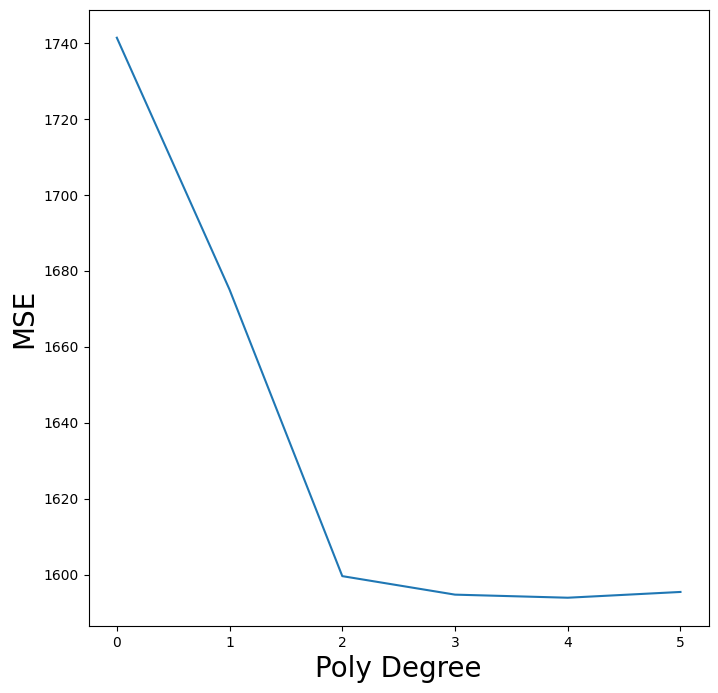

In [418]:
ax = subplots(figsize=(8,8))[1]
ax.plot(linear_poly_cv.cv_results_['param_poly__degree'], -linear_poly_cv.cv_results_['mean_test_score'])
ax.set_xlabel('Poly Degree', fontsize=20)
ax.set_ylabel('MSE', fontsize=20)

In [419]:
predicoes = linear_poly_cv.predict(X_age)
print('RSS melhor modelo grid cv :',np.sum((predicoes - y)**2))

RSS melhor modelo grid cv : 4771604.24882639


In [420]:
models = [ModelSpec([poly('age', degree=d)]) for d in range(1,6)]
Xs = [model.fit_transform(Wage) for model in models]
anova_lm (*[OLS(y,X_).fit() for  X_ in Xs])

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2998.0,5.022216e+06,0.0,NaN,NaN,NaN
1,2997.0,4.793430e+06,1.0,228786.010128,143.593107,2.363850e-32
2,2996.0,4.777674e+06,1.0,15755.693664,9.888756,1.679202e-03
3,2995.0,4.771604e+06,1.0,6070.152124,3.809813,5.104620e-02
4,2994.0,4.770322e+06,1.0,1282.563017,0.804976,3.696820e-01


Text(0.5, 1.0, "Age x Wage {'poly__degree': 4}")

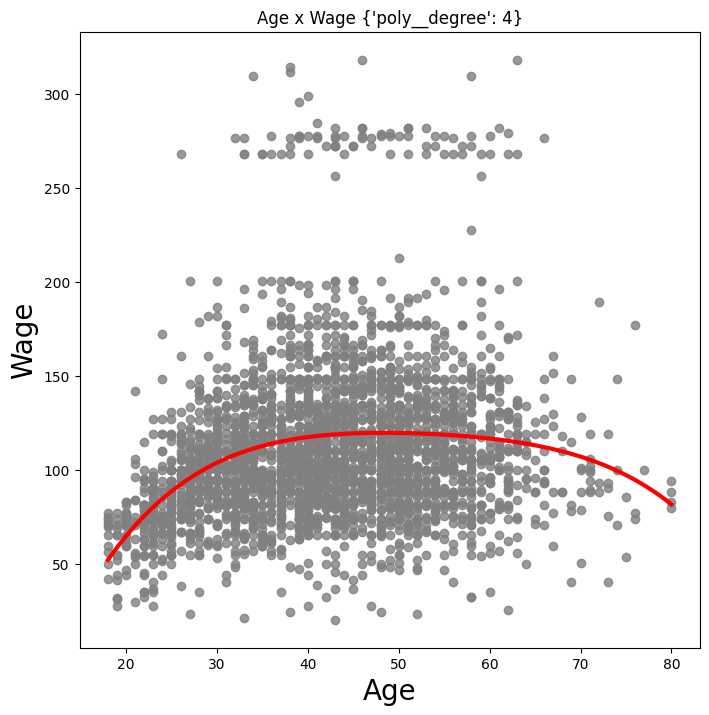

In [421]:
fig, ax = subplots(figsize=(8,8))
ax.scatter(X_age, y, facecolor='gray', alpha=0.8)
lin_idade_min_max = pd.DataFrame({'age':np.linspace(X_age.age.min(),X_age.age.max(), 100)})
ax.plot(lin_idade_min_max, linear_poly_cv.predict(lin_idade_min_max), '-r', linewidth=3)
ax.set_xlabel('Age', fontsize=20)
ax.set_ylabel('Wage', fontsize=20)
ax.set_title(f'Age x Wage {linear_poly_cv.best_params_}')

Ambos os resultados chegaram na mesma solução de 4

b) Fit a step function to predict wage using age, and perform cross
validation to choose the optimal number of cuts. Make a plot of
the fit obtained.

In [422]:
from sklearn.preprocessing import KBinsDiscretizer

pipe_age_kbins = Pipeline([
    ('discretizer', KBinsDiscretizer(quantile_method='averaged_inverted_cdf',n_bins=2, encode='onehot')),
    ('linear', LinearRegression())
])
grid_kbins = {'discretizer__n_bins': range(2,25),
              'discretizer__strategy': ['quantile','uniform', 'kmeans']}
linear_kbins_cv = GridSearchCV(pipe_age_kbins,
             grid_kbins,
             cv=5,
             scoring='neg_mean_squared_error')
linear_kbins_cv.fit(X_age,y)
linear_kbins_cv.best_params_

{'discretizer__n_bins': 13, 'discretizer__strategy': 'kmeans'}

In [423]:
pd.DataFrame(linear_kbins_cv.cv_results_).sort_values(by='mean_test_score',ascending=False).head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_discretizer__n_bins,param_discretizer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
35,0.007817,0.001140,0.002329,0.000967,13,kmeans,"{'discretizer__n_bins': 13, 'discretizer__stra...",-1761.867356,-1520.806284,-1457.600490,-1612.205217,-1644.149938,-1599.325857,104.734157,1
44,0.007931,0.001152,0.002323,0.000526,16,kmeans,"{'discretizer__n_bins': 16, 'discretizer__stra...",-1753.082566,-1529.477461,-1452.747641,-1609.172735,-1652.226177,-1599.341316,102.859614,2
43,0.005231,0.000228,0.002665,0.001304,16,uniform,"{'discretizer__n_bins': 16, 'discretizer__stra...",-1754.077350,-1529.477461,-1453.098651,-1609.032775,-1654.459778,-1600.029203,103.286707,3
34,0.004907,0.000481,0.003379,0.001469,13,uniform,"{'discretizer__n_bins': 13, 'discretizer__stra...",-1761.934456,-1524.838830,-1457.600490,-1615.030173,-1648.092019,-1601.499194,104.572559,4
19,0.006120,0.001052,0.002946,0.001724,8,uniform,"{'discretizer__n_bins': 8, 'discretizer__strat...",-1761.459879,-1527.176201,-1457.934475,-1610.577474,-1656.072716,-1602.644149,104.667365,5


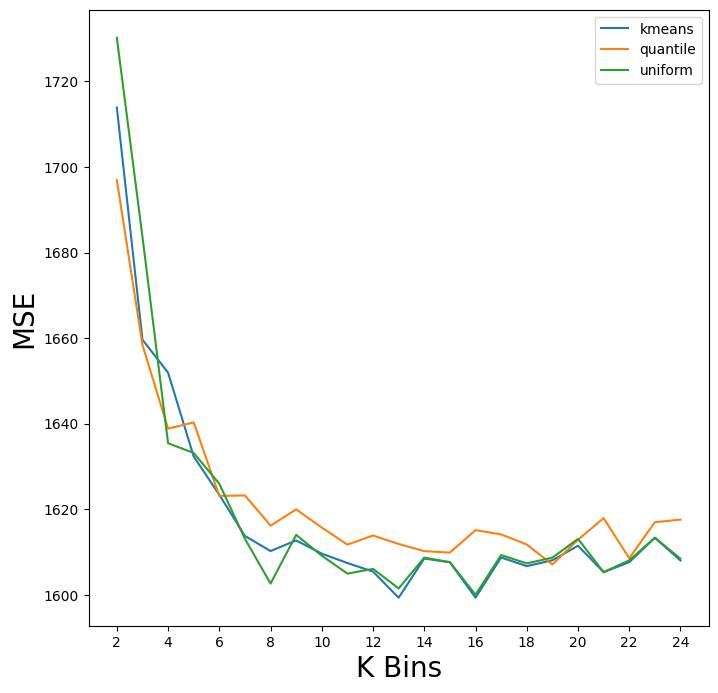

In [424]:
fig, ax = subplots(figsize=(8,8))
bilada = pd.DataFrame(linear_kbins_cv.cv_results_).sort_values(by='param_discretizer__n_bins',ascending=False).groupby('param_discretizer__strategy')
for s, df in bilada:
    ax.plot(df['param_discretizer__n_bins'], -df['mean_test_score'], label=s)
ax.set_xticks(range(2,25,2));
ax.set_xlabel('K Bins', fontsize=20)
ax.set_ylabel('MSE', fontsize=20)
ax.legend();

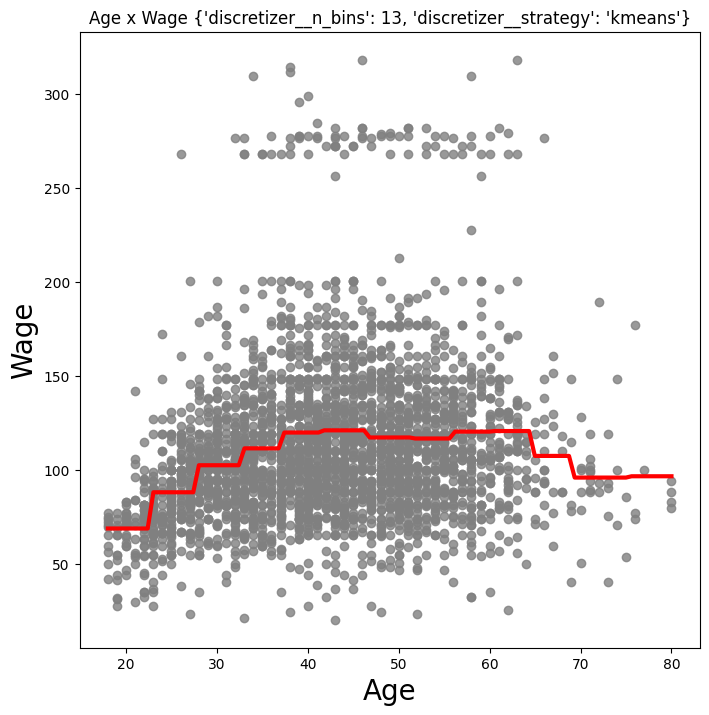

In [425]:
fig, ax = subplots(figsize=(8,8))
ax.scatter(X_age, y, facecolor='gray', alpha=0.8)
ax.plot(lin_idade_min_max, linear_kbins_cv.predict(lin_idade_min_max), '-r', linewidth=3)
ax.set_xlabel('Age', fontsize=20)
ax.set_ylabel('Wage', fontsize=20)
ax.set_title(f'Age x Wage {linear_kbins_cv.best_params_}');

# 7 #
The Wage data set contains a number of other features not explored
in this chapter, such as marital status (maritl), job class (jobclass),
and others. Explore the relationships between some of these other
predictors and wage, and use non-linear fitting techniques in order to
fit flexible models to the data. Create plots of the results obtained,
and write a summary of your findings.

In [426]:
Wage.maritl.cat.categories, Wage.jobclass.cat.categories,

(Index(['1. Never Married', '2. Married', '3. Widowed', '4. Divorced',
        '5. Separated'],
       dtype='object'),
 Index(['1. Industrial', '2. Information'], dtype='object'))

In [427]:
from pygam import (f as f_gam,
                   l as l_gam,
                   s as s_gam, 
                   LinearGAM)
from ISLP.pygam import plot as plot_gam

In [428]:
lgam = LinearGAM(f_gam(0) + f_gam(1) + f_gam(2) + f_gam(3) + s_gam(4))
Xgam = np.column_stack([Wage.maritl.cat.codes, Wage.jobclass.cat.codes, Wage.education.cat.codes, Wage.health.cat.codes, Wage.age])

lgam.fit(Xgam, y)

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, 
   terms=f(0) + f(1) + f(2) + f(3) + s(4) + intercept, tol=0.0001, 
   verbose=False)

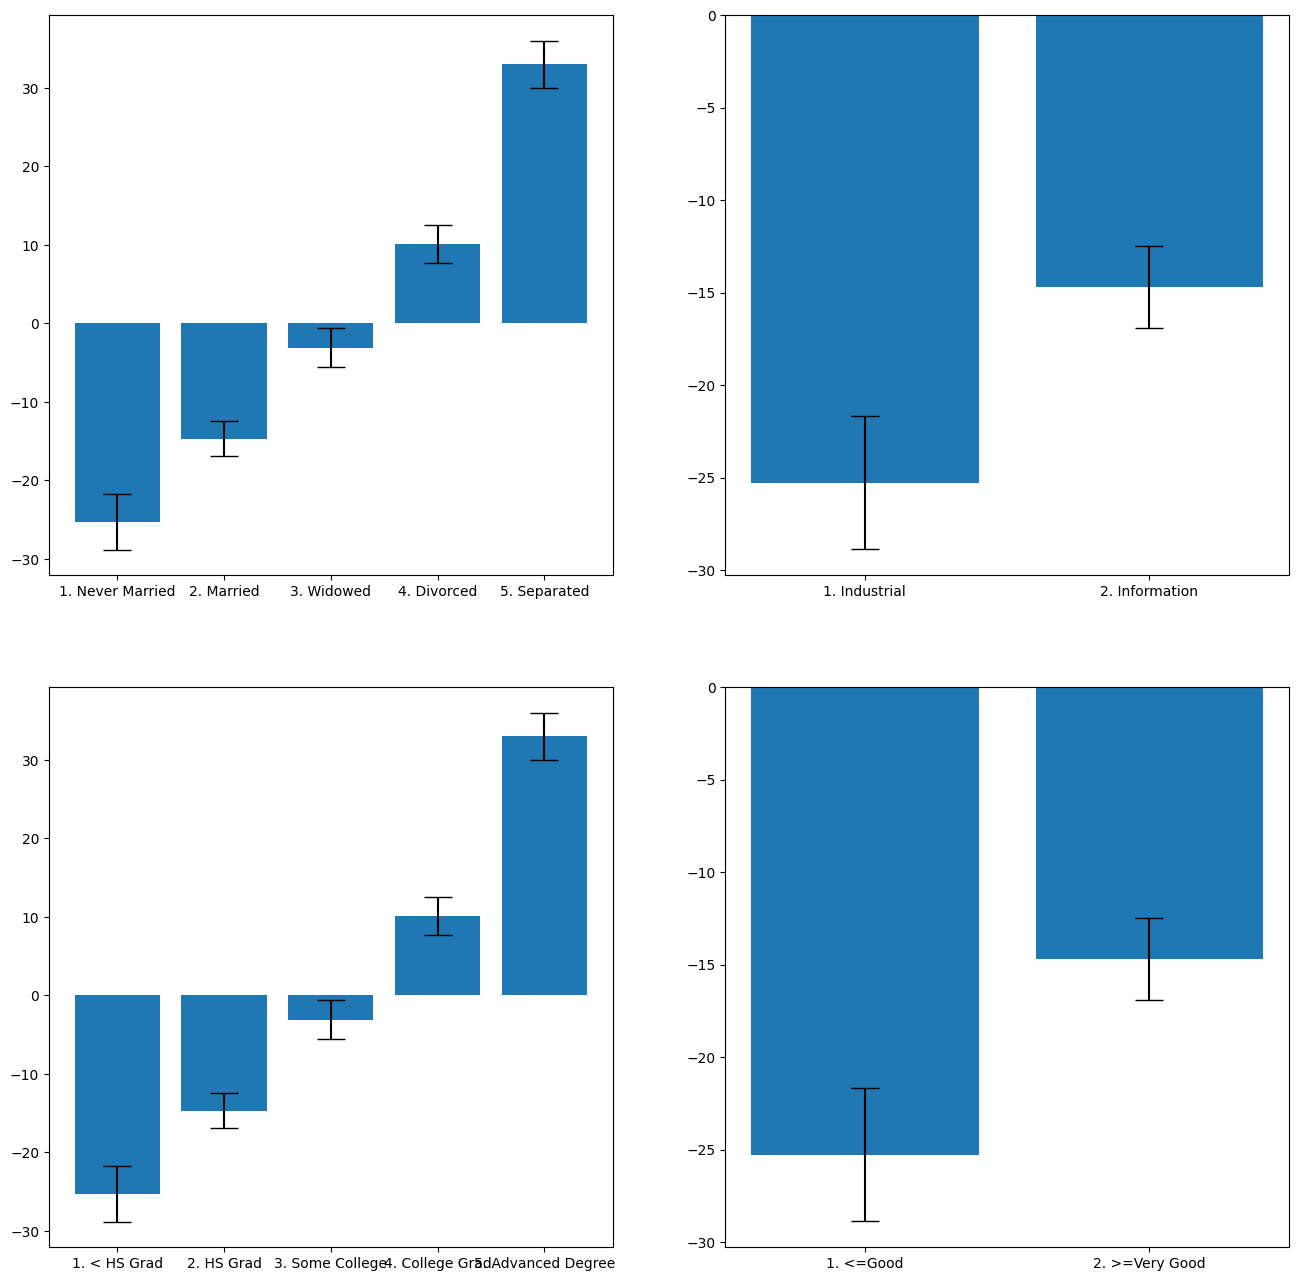

In [429]:
categorias = [Wage.maritl.cat.categories, Wage.jobclass.cat.categories, Wage.education.cat.categories, Wage.health.cat.categories]
_, axes = subplots(2,2, figsize=(16, 16))
axes = axes.flatten()
for i, cat in enumerate(categorias):
    ax = axes[i]
    plot_gam(lgam, i, ax=ax)
    ax.set_xticklabels(cat)

In [430]:
lgam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     25.1569
Link Function:                     IdentityLink Log Likelihood:                                -14877.7093
Number of Samples:                         3000 AIC:                                            29807.7323
                                                AICc:                                           29808.2101
                                                GCV:                                             1217.0426
                                                Scale:                                              34.622
                                                Pseudo R-Squared:                                   0.3171
Feature Function                  Lam

C:\Users\olive\AppData\Local\Temp\ipykernel_13396\1597928117.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  lgam.summary()


In [431]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y,lgam.predict(Xgam))

1188.6344680776363

In [432]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer([
    ('one', OneHotEncoder(), ['maritl','jobclass', 'education', 'health'])
],
remainder='passthrough'
)

pipe_lin = Pipeline([
    ('prepocessamento', ct),
    ('linear', LinearRegression())
])

pipe_lin.fit(Wage[['maritl','jobclass', 'education','health', 'age']], y)
mean_squared_error(y, pipe_lin.predict(Wage[['maritl','jobclass', 'education','health', 'age']]))

1218.871699899688

Utilizando os mesmos preditores o modelo GAM obteve melhor resultado, nesse caso não necessariamente por causa da regularização $\ell^2$ para cada modelo preditor foi por causa do modelo para o preditor `age` ser `spline` e explicar melhor Y. O objetivo central foi entender o funcionamento do GAM(Generalized Additive Models) e utilizar em uma comparação simples.